# ARTI 403 – Image Processing
## Lab 5: Spatial Filtering – Smoothing and Sharpening
### Name: Abdullah Alnaji
### ID: 2240007157
**Images:** taken from the scikit-image general-purpose dataset (`skimage.data`, see [gallery](https://scikit-image.org/docs/stable/auto_examples/data/plot_general.html)) and saved in the `images/` folder.

## 0. Setup – import libraries and save the images to `images/`

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io

os.makedirs('images', exist_ok=True)

# Images from the scikit-image general-purpose dataset
images = {
    'camera.png':    data.camera(),     # RGB  - procedural task (unsharp masking) and RGB  - assessment task 2 (Gaussian filters)
    'cat.png':    data.cat(),     # gray - assessment task 1 (box filter) and gray - assessment task 3 (Laplacian sharpening)
}
for name, img in images.items():
    io.imsave(os.path.join('images', name), img, check_contrast=False)
    print(f'{name:15s} shape={img.shape}, dtype={img.dtype}')

camera.png      shape=(512, 512), dtype=uint8
cat.png         shape=(300, 451, 3), dtype=uint8


## 1. Procedural Task – Unsharp Masking
The manual uses `Parrot.png`; we use the **camera** image from scikit-image instead.

$$\text{sharpened} = f + k\,(f - f_{blur}),\qquad \sigma = 2,\; k = 1.5$$

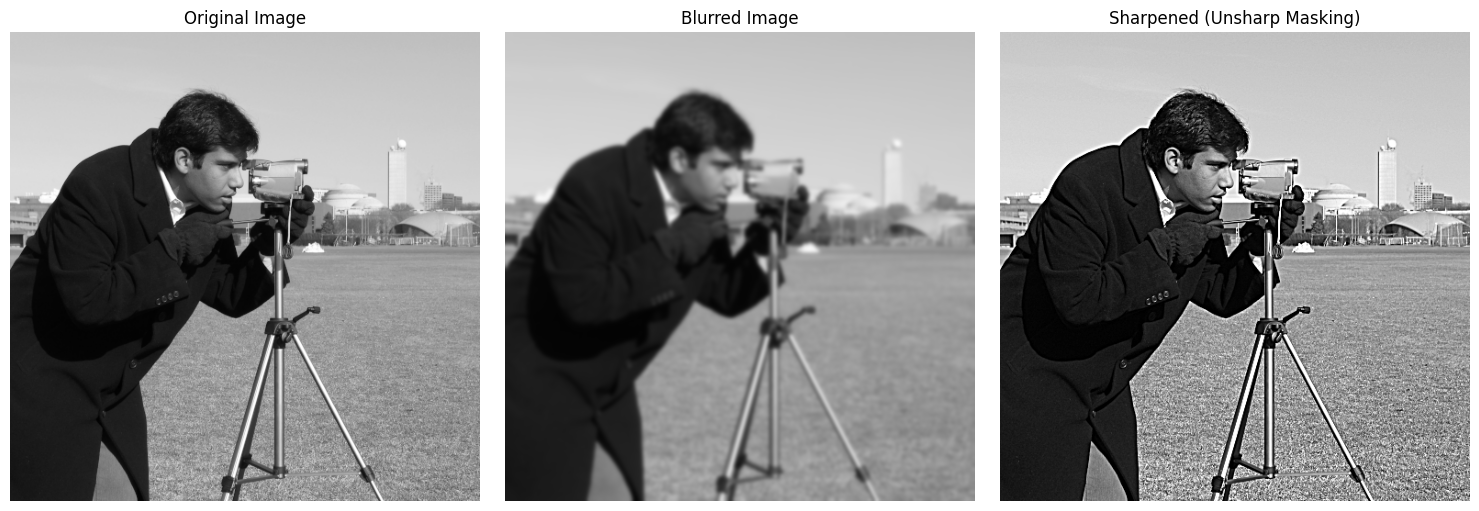

In [2]:
# Read the image
image = cv2.imread('images/camera.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

sigma = 2      # Gaussian sigma
amount = 1.5   # unsharp-mask strength

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);     ax[0].set_title('Original Image')
ax[1].imshow(blurred);   ax[1].set_title('Blurred Image')
ax[2].imshow(sharpened); ax[2].set_title('Sharpened (Unsharp Masking)')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

# Assessment
## Task 1 – Convolve an image with a 7×7 box filter
A box (mean) filter replaces each pixel with the average of its 7×7 neighbourhood: every kernel weight equals $1/49$.

[[0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]]
Same as cv2.blur: True


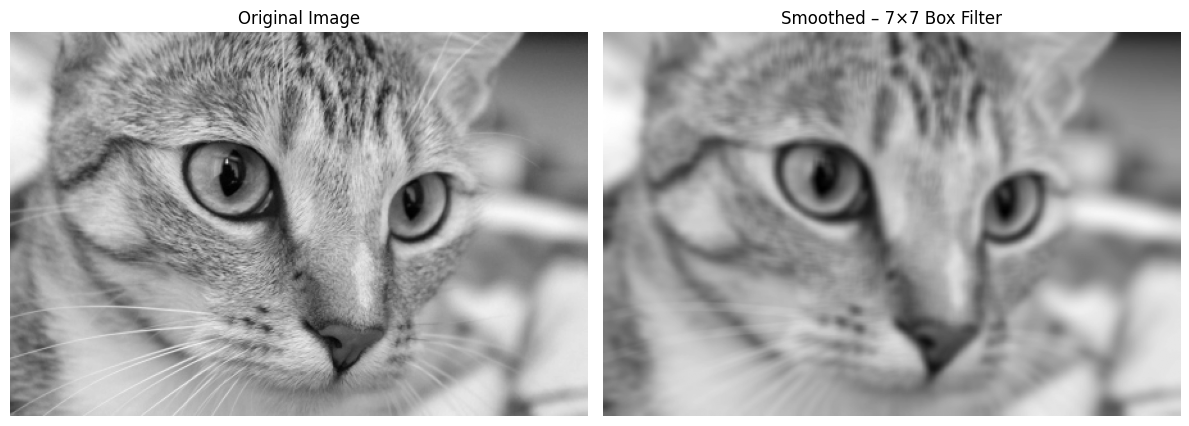

In [3]:
img1 = cv2.imread('images/cat.png', cv2.IMREAD_GRAYSCALE)

# 7x7 box kernel (all weights = 1/49)
box_kernel = np.ones((7, 7), np.float32) / 49
print(box_kernel.round(4))

# Convolve the image with the kernel
box_smoothed = cv2.filter2D(img1, -1, box_kernel)

# (Check: same result as OpenCV's built-in box filter)
print('Same as cv2.blur:', np.array_equal(box_smoothed, cv2.blur(img1, (7, 7))))

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img1, cmap='gray');         ax[0].set_title('Original Image')
ax[1].imshow(box_smoothed, cmap='gray'); ax[1].set_title('Smoothed – 7×7 Box Filter')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## Task 2 – 5×5 and 21×21 Gaussian filters
With `sigmaX=0`, OpenCV computes σ from the kernel size: $\sigma = 0.3\,((k-1)/2 - 1) + 0.8$.

5x5 kernel -> sigma = 1.10
21x21 kernel -> sigma = 3.50


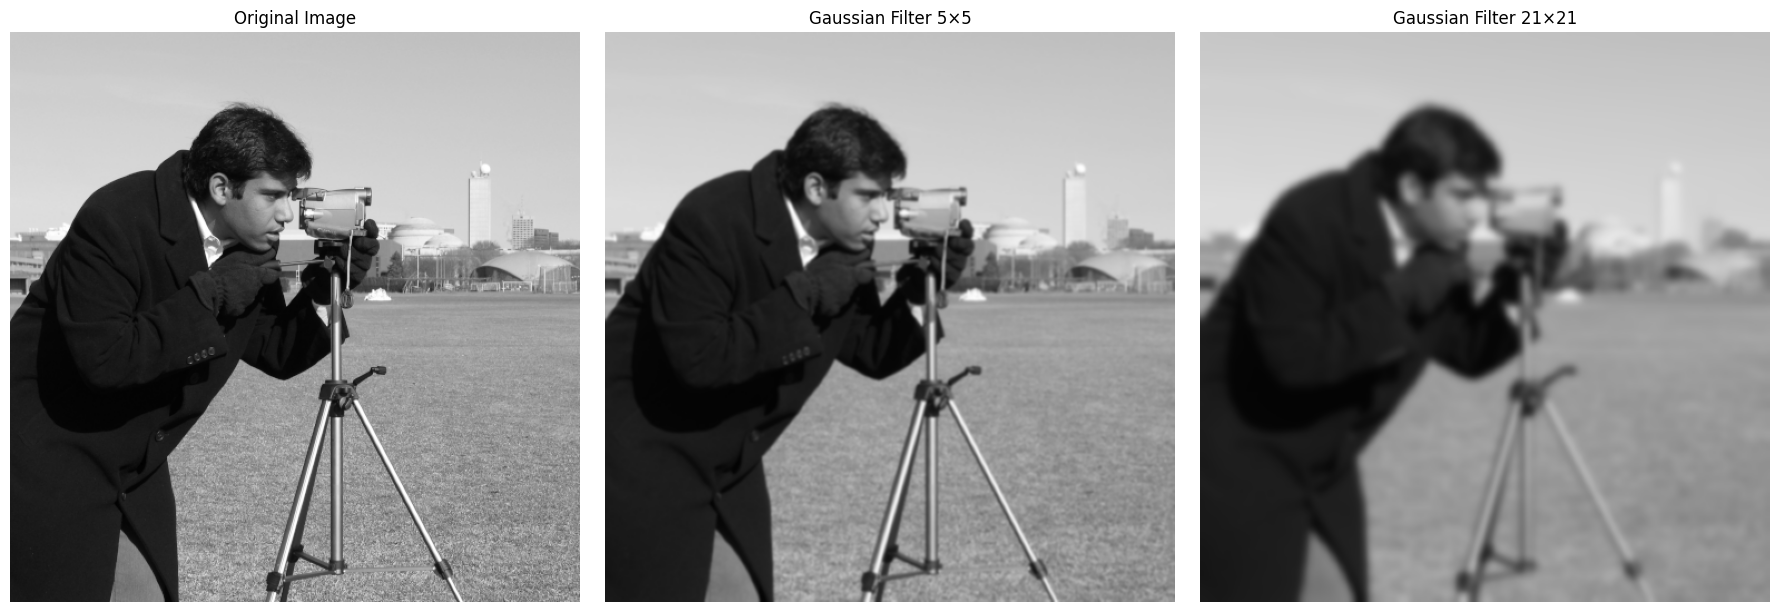

In [4]:
img2 = cv2.imread('images/camera.png')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

gauss_5  = cv2.GaussianBlur(img2, (5, 5), 0)
gauss_21 = cv2.GaussianBlur(img2, (21, 21), 0)

for k in (5, 21):
    print(f'{k}x{k} kernel -> sigma = {0.3 * ((k - 1) / 2 - 1) + 0.8:.2f}')

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(img2);     ax[0].set_title('Original Image')
ax[1].imshow(gauss_5);  ax[1].set_title('Gaussian Filter 5×5')
ax[2].imshow(gauss_21); ax[2].set_title('Gaussian Filter 21×21')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## Task 3 – Sharpening with a 3×3 Laplacian filter
`cv2.Laplacian` with `ksize=1` uses the 3×3 kernel

$$\begin{bmatrix}0&1&0\\1&-4&1\\0&1&0\end{bmatrix}$$

Because the centre coefficient is negative, the sharpened image is $g = f - \nabla^2 f$.

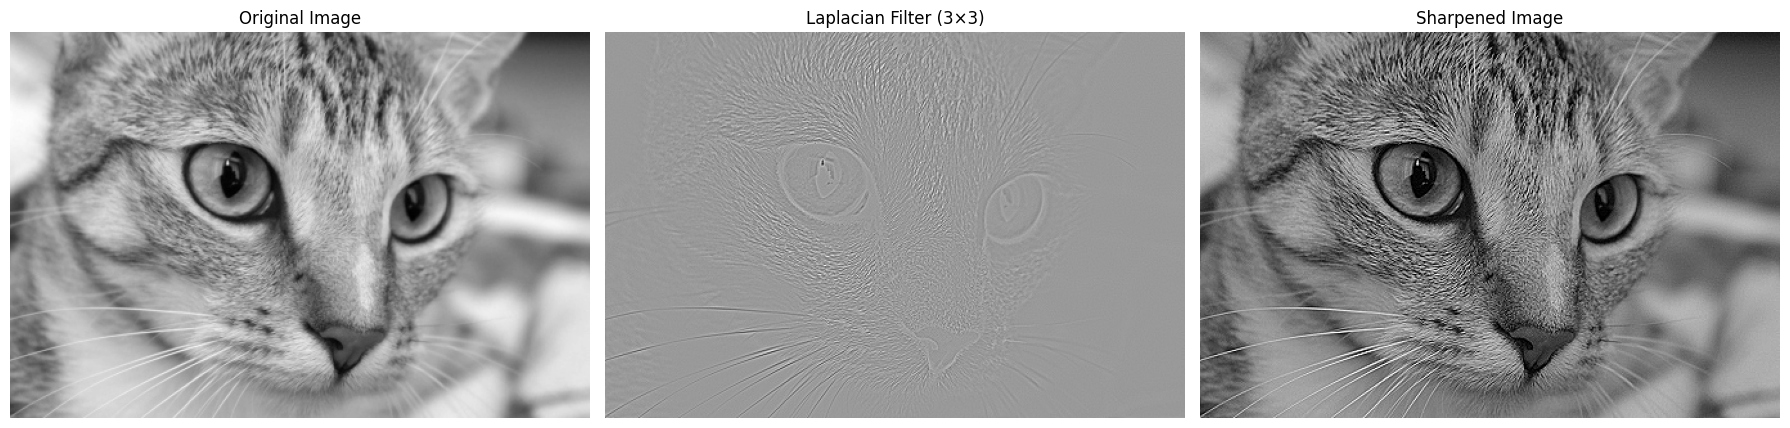

In [5]:
# 1. Read the image
img3 = cv2.imread('images/cat.png', cv2.IMREAD_GRAYSCALE)

# 2. Convert image to float32
image_float = img3.astype(np.float32) / 255.0

# 3. Apply the 3x3 Laplacian
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=1)

# 4. Sharpen the image
sharpened = np.clip(image_float - laplacian, 0, 1)

# 5. Plot original, Laplacian, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(image_float, cmap='gray');          ax[0].set_title('Original Image')
ax[1].imshow(laplacian, cmap='gray');            ax[1].set_title('Laplacian Filter (3×3)')
ax[2].imshow(sharpened, cmap='gray', vmin=0, vmax=1); ax[2].set_title('Sharpened Image')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()